# Lab 6: REINFORCE and Actor-Critic with PyTorch

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import gymnasium as gym, numpy as np, matplotlib.pyplot as plt
from torch.distributions import Categorical, Normal
torch.set_num_threads(1)

## Part 1 - REINFORCE on CartPole-v1

### Policy and value networks (3 hidden layers)

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_act, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_act))
    def forward(self, s): return self.net(s)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, s): return self.net(s).squeeze(-1)

### Episode rollout and return computation

In [ ]:
def run_episode(env, policy):
    s, _ = env.reset()
    log_probs, rewards, states = [], [], []
    done = False
    while not done:
        st = torch.as_tensor(s, dtype=torch.float32)
        probs = F.softmax(policy(st), dim=-1)
        dist = Categorical(probs)
        a = dist.sample()
        log_probs.append(dist.log_prob(a))
        states.append(st)
        s, r, term, trunc, _ = env.step(int(a))
        rewards.append(r)
        done = term or trunc
    return log_probs, rewards, states

def returns(rewards, gamma):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    return torch.tensor(list(reversed(out)), dtype=torch.float32)

### REINFORCE training loop (with optional state-value baseline)

In [ ]:
def train_reinforce(seed, n_episodes=250, gamma=0.99, lr=3e-3, baseline=False):
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make('CartPole-v1'); env.reset(seed=seed)
    policy = PolicyNet(4, 2)
    p_opt = torch.optim.Adam(policy.parameters(), lr=lr)
    if baseline:
        value = ValueNet(4)
        v_opt = torch.optim.Adam(value.parameters(), lr=lr)
    rets = np.zeros(n_episodes)
    for ep in range(n_episodes):
        log_probs, rewards, states = run_episode(env, policy)
        G = returns(rewards, gamma)
        if baseline:
            V = value(torch.stack(states))
            adv = G - V.detach()
            v_opt.zero_grad(); F.mse_loss(V, G).backward(); v_opt.step()
        else:
            adv = G
        loss = -(torch.stack(log_probs) * adv).sum()
        p_opt.zero_grad(); loss.backward(); p_opt.step()
        rets[ep] = sum(rewards)
    return rets, policy

### Train both variants across 5 seeds

In [ ]:
N_EP, N_SEEDS = 250, 5
ret_no, ret_bl = np.zeros((N_SEEDS, N_EP)), np.zeros((N_SEEDS, N_EP))
policy_no = policy_bl = None
for s in range(N_SEEDS):
    ret_no[s], policy_no = train_reinforce(s, N_EP, baseline=False)
    ret_bl[s], policy_bl = train_reinforce(s, N_EP, baseline=True)
print(f"no baseline last-50 mean = {ret_no[:, -50:].mean():.1f}")
print(f"with baseline last-50 mean = {ret_bl[:, -50:].mean():.1f}")

### Save trained policies

In [ ]:
torch.save(policy_no.state_dict(), 'reinforce_no_baseline.pt')
torch.save(policy_bl.state_dict(), 'reinforce_baseline.pt')

### Figure 1 - learning curves with 95% confidence intervals

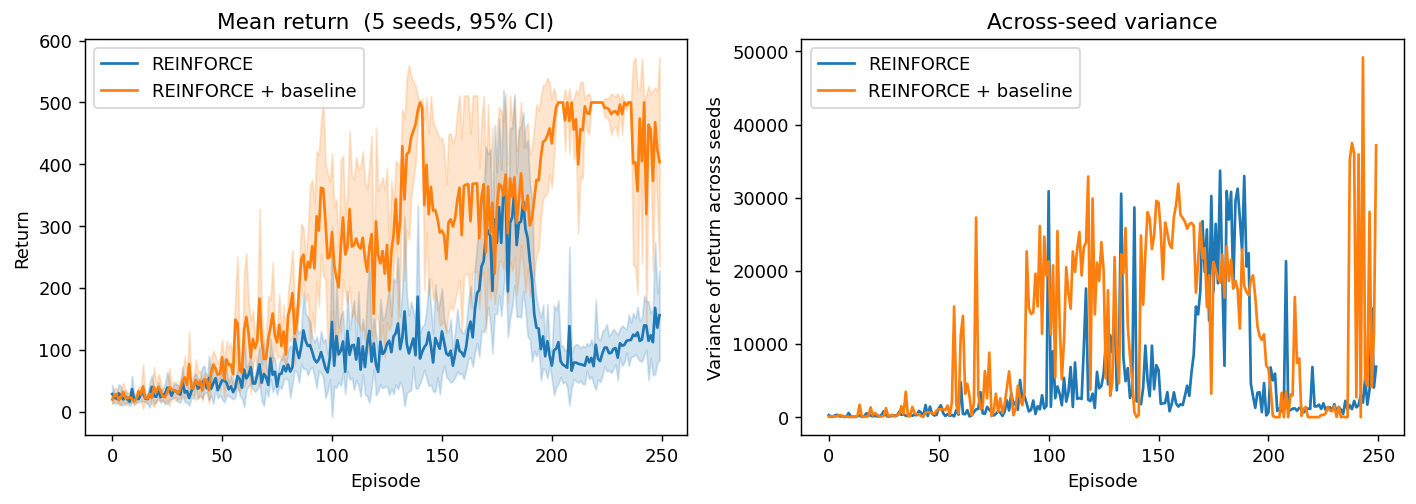

In [ ]:
def band(ax, data, label, color):
    mean = data.mean(0)
    ci = 1.96 * data.std(0) / np.sqrt(data.shape[0])
    x = np.arange(len(mean))
    ax.plot(x, mean, color=color, label=label)
    ax.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
band(axes[0], ret_no, 'REINFORCE', 'C0')
band(axes[0], ret_bl, 'REINFORCE + baseline', 'C1')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title(f'Mean return  ({N_SEEDS} seeds, 95% CI)'); axes[0].legend()
axes[1].plot(ret_no.var(0), color='C0', label='REINFORCE')
axes[1].plot(ret_bl.var(0), color='C1', label='REINFORCE + baseline')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Variance of return across seeds')
axes[1].set_title('Across-seed variance'); axes[1].legend()
plt.tight_layout(); plt.show()

## Part 2 - Online Actor-Critic with TD(0) on Pendulum-v1

Continuous action space. Actor outputs Gaussian (mean, log-std), critic outputs V(s).
Update each step: delta = r + gamma V(s') - V(s); critic minimises delta^2; actor uses -log_prob * delta.detach() (with a small entropy bonus).

### Actor and critic networks (2 hidden layers, Tanh)

In [ ]:
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh())
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.full((act_dim,), 0.0))
    def forward(self, s):
        h = self.body(s)
        return self.mu(h), self.log_std.exp()

class Critic(nn.Module):
    def __init__(self, obs_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1))
    def forward(self, s): return self.net(s).squeeze(-1)

### Training loop

In [ ]:
def train_ac(seed=0, n_episodes=200, gamma=0.99, a_lr=2e-3, c_lr=5e-3, r_scale=10.0, ent_coef=0.01):
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make('Pendulum-v1'); env.reset(seed=seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    a_low = torch.as_tensor(env.action_space.low, dtype=torch.float32)
    a_high = torch.as_tensor(env.action_space.high, dtype=torch.float32)
    actor, critic = Actor(obs_dim, act_dim), Critic(obs_dim)
    a_opt = torch.optim.Adam(actor.parameters(), lr=a_lr)
    c_opt = torch.optim.Adam(critic.parameters(), lr=c_lr)
    rets, ents, td_mags = [], [], []
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, ep_ret, ep_td, n_steps = False, 0.0, 0.0, 0
        while not done:
            st = torch.as_tensor(s, dtype=torch.float32)
            mu, sigma = actor(st)
            dist = Normal(mu, sigma)
            a = dist.sample()
            a_clipped = torch.clamp(a, a_low, a_high)
            log_prob = dist.log_prob(a).sum()
            s2, r, term, trunc, _ = env.step(a_clipped.numpy())
            done = term or trunc
            v = critic(st)
            with torch.no_grad():
                v_next = critic(torch.as_tensor(s2, dtype=torch.float32)) * (0.0 if done else 1.0)
                target = r / r_scale + gamma * v_next
            delta = target - v
            c_opt.zero_grad(); (delta**2).mean().backward(); c_opt.step()
            a_loss = -log_prob * delta.detach() - ent_coef * dist.entropy().sum()
            a_opt.zero_grad(); a_loss.backward(); a_opt.step()
            ep_ret += r; ep_td += abs(delta.item()); n_steps += 1
            s = s2
        rets.append(ep_ret)
        ents.append(0.5 * (1 + np.log(2*np.pi) + 2*actor.log_std.detach().mean().item()))
        td_mags.append(ep_td / n_steps)
    return actor, critic, np.array(rets), np.array(ents), np.array(td_mags)

### Train and save

In [ ]:
actor, critic, rets, ents, td_mags = train_ac(seed=0, n_episodes=200)
print(f"first-50 mean return = {rets[:50].mean():.1f}")
print(f"last-50  mean return = {rets[-50:].mean():.1f}")
torch.save(actor.state_dict(), 'ac_actor.pt')
torch.save(critic.state_dict(), 'ac_critic.pt')

### Figure 2 - return per episode

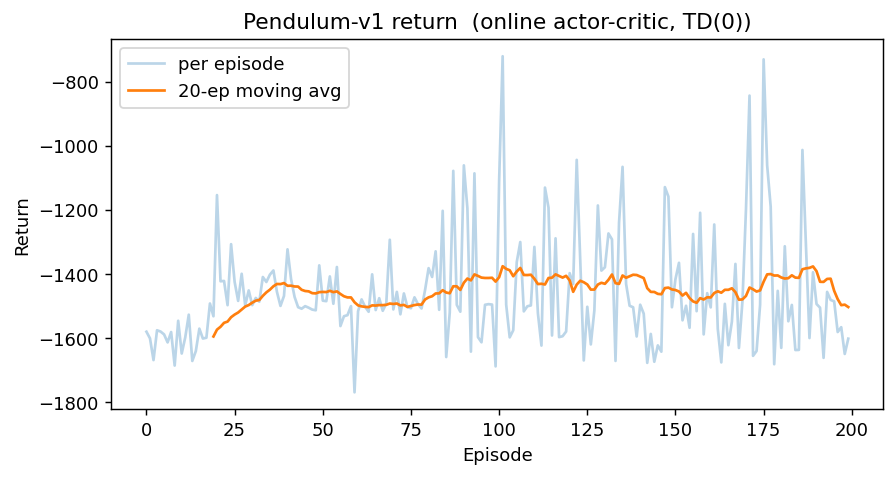

In [ ]:
plt.figure(figsize=(7, 3.8))
plt.plot(rets, alpha=0.3, label='per episode')
w = 20
plt.plot(np.arange(w-1, len(rets)), np.convolve(rets, np.ones(w)/w, mode='valid'), color='C1', label=f'{w}-ep moving avg')
plt.xlabel('Episode'); plt.ylabel('Return'); plt.title('Pendulum-v1 return  (online actor-critic, TD(0))')
plt.legend(); plt.tight_layout(); plt.show()

### Figure 3 - policy entropy and TD-error magnitude

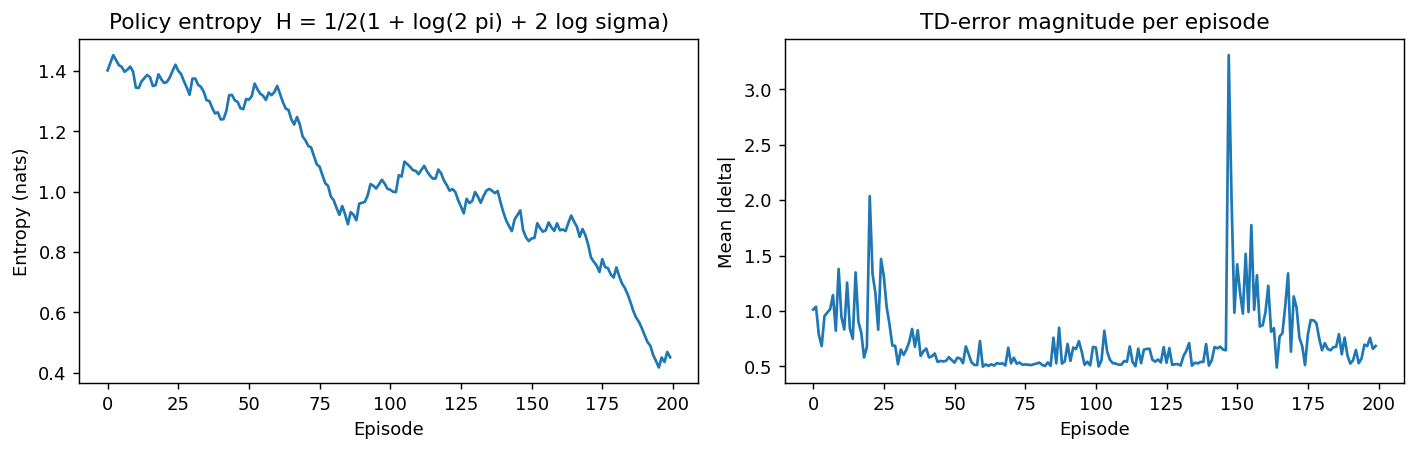

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(ents); axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Entropy (nats)')
axes[0].set_title('Policy entropy  H = 1/2(1 + log(2 pi) + 2 log sigma)')
axes[1].plot(td_mags); axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean |delta|')
axes[1].set_title('TD-error magnitude per episode')
plt.tight_layout(); plt.show()

### Figure 4 - sample trajectories from the learned (deterministic) policy

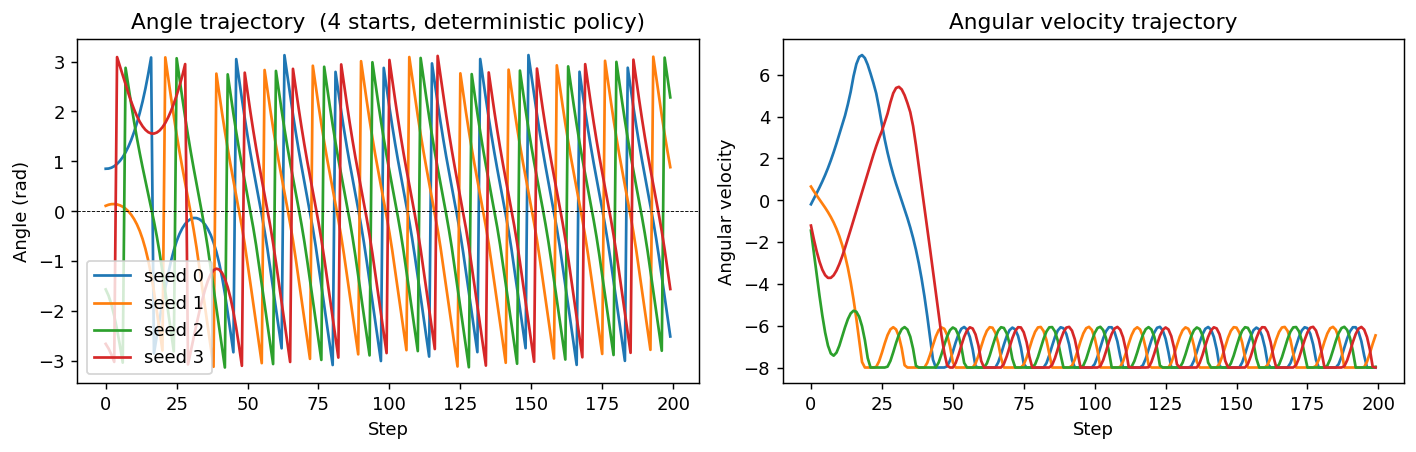

In [ ]:
def rollout(env, actor, n=200, seed=0):
    s, _ = env.reset(seed=seed)
    angs, vels = [], []
    for _ in range(n):
        st = torch.as_tensor(s, dtype=torch.float32)
        with torch.no_grad():
            mu, _ = actor(st)
        a = torch.clamp(mu, -2.0, 2.0).numpy()
        s, _, term, trunc, _ = env.step(a)
        angs.append(np.arctan2(s[1], s[0])); vels.append(s[2])
        if term or trunc: break
    return np.array(angs), np.array(vels)

env = gym.make('Pendulum-v1')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for sd in range(4):
    a, v = rollout(env, actor, seed=sd)
    axes[0].plot(a, label=f'seed {sd}')
    axes[1].plot(v)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('Angle trajectory  (4 starts, deterministic policy)'); axes[0].axhline(0, color='k', lw=0.5, ls='--'); axes[0].legend()
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Angular velocity'); axes[1].set_title('Angular velocity trajectory')
plt.tight_layout(); plt.show()

### Figure 5 - learned mean action across the (angle, velocity) state space

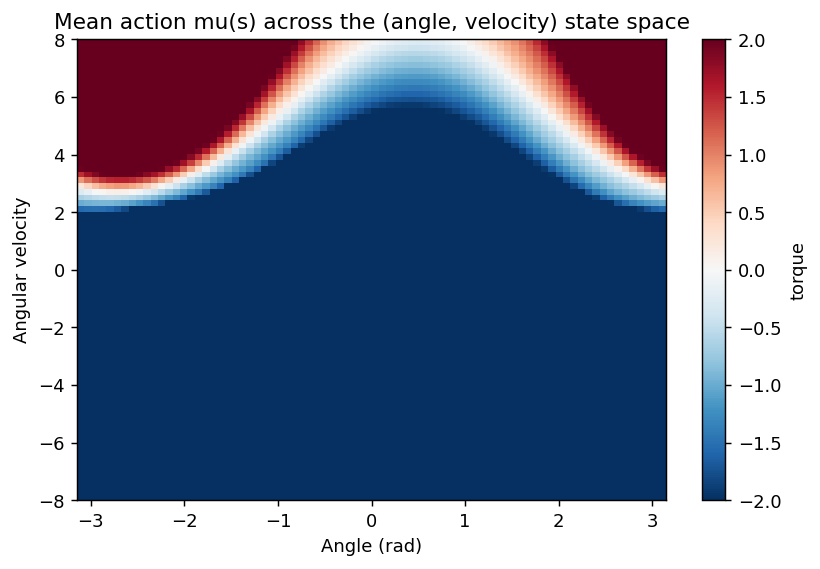

In [ ]:
angs = np.linspace(-np.pi, np.pi, 80)
vels = np.linspace(-8, 8, 80)
A, V = np.meshgrid(angs, vels)
states = np.stack([np.cos(A), np.sin(A), V], axis=-1).reshape(-1, 3)
with torch.no_grad():
    mu, _ = actor(torch.as_tensor(states, dtype=torch.float32))
mu = mu.numpy().reshape(A.shape)

plt.figure(figsize=(6.5, 4.5))
im = plt.imshow(mu, origin='lower', aspect='auto',
                extent=[-np.pi, np.pi, -8, 8], cmap='RdBu_r', vmin=-2, vmax=2)
plt.xlabel('Angle (rad)'); plt.ylabel('Angular velocity')
plt.title('Mean action mu(s) across the (angle, velocity) state space')
plt.colorbar(im, label='torque')
plt.tight_layout(); plt.show()